In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [3]:
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [4]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


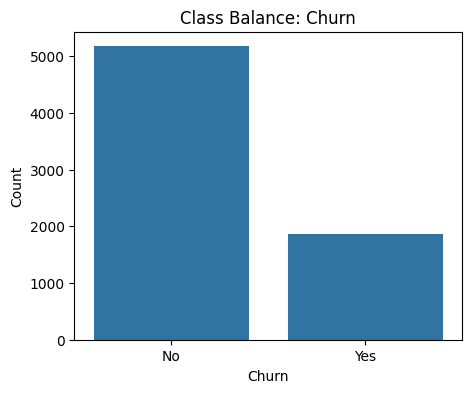

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title('Class Balance: Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [6]:
# Drop customerID (not useful for prediction), and BOTH target-related columns
# to prevent data leakage
df_encoded = df.drop(columns=['customerID', 'Churn', 'Churn_numeric'])
df_encoded = pd.get_dummies(df_encoded, drop_first=True)

X = df_encoded
y = df['Churn_numeric']

# Sanity check: confirm target is NOT in features
print(X.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression

log_model_original = LogisticRegression(max_iter=1000)
log_model_original.fit(X_train, y_train)
pred_original = log_model_original.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
log_model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model_balanced.fit(X_train, y_train)
pred_balanced = log_model_balanced.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.metrics import classification_report

print("=== Original Model (No Balancing) ===")
print(classification_report(y_test, pred_original, target_names=['No Churn', 'Churn']))

print("\n=== Balanced Model (class_weight='balanced') ===")
print(classification_report(y_test, pred_balanced, target_names=['No Churn', 'Churn']))

=== Original Model (No Balancing) ===
              precision    recall  f1-score   support

    No Churn       0.86      0.90      0.88      1036
       Churn       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


=== Balanced Model (class_weight='balanced') ===
              precision    recall  f1-score   support

    No Churn       0.92      0.72      0.81      1036
       Churn       0.52      0.84      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.75      0.77      1409



## Before vs After Balancing

| Metric (Churn class) | Original Model | Balanced Model |
|---|---|---|
| Precision | 0.69 | 0.52 |
| Recall | 0.60 | 0.84 |
| F1-score | 0.64 | 0.64 |
| Overall Accuracy | 82% | 75% |

Applying class_weight='balanced' significantly improved recall for the
Churn class, from 60% to 84% — meaning the model now catches far more
at-risk customers. This came at the cost of precision (0.69 to 0.52) and
overall accuracy (82% to 75%), since the model now flags more false
alarms. For a churn prediction use case, this trade-off is usually
worthwhile: failing to identify a customer who is about to leave is
more costly to the business than occasionally flagging a customer who
was actually going to stay.

## Why Accuracy Would Be Misleading Here

Only about 27% of customers in this dataset churned, while 73% did not.
The original model achieved 82% accuracy, which sounds strong, but its
recall for the Churn class was only 60% — meaning it missed 40% of the
customers who actually left. A high accuracy score was hiding this weak
performance on the class that actually matters most for the business.
After applying class weighting, Churn recall improved to 84%, even
though overall accuracy dropped to 75%. This confirms that accuracy
alone was a misleading metric here, since it rewarded the model for
correctly predicting the easy majority class (No Churn) while masking
its failure to catch actual churners.